Посмотрим на пропуски и дубликаты

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import iqr

raw = pd.read_csv("../data/raw/diamonds.csv")
assert not any(raw.isna().any())  # Нет пропущенных значений

row_count = len(raw)

# Удаляем дубликаты
raw.drop_duplicates(inplace=True)
print(f"{row_count - len(raw)} дубликатов удалено")

126 дубликатов удалено


In [2]:
raw["cut"].value_counts()

cut
Ideal        19881
Premium      12769
Very Good    11194
Good          4547
Fair          1483
Name: count, dtype: int64

Выглядит так, что чем "лучше" значение, тем чаще оно встречается в датасете.

In [3]:
raw["color"].value_counts()

color
G    10424
E     9067
F     8844
H     7683
D     6209
I     5045
J     2602
Name: count, dtype: int64

Цитата из датасета:

```
diamond color from J (worst) to D (best)
```

Видим, что порядок частот значений не вполне совпадает с предложенным порядком из датасета.

In [4]:
raw["clarity"].value_counts()

clarity
SI1     12086
VS2     11378
SI2      8483
VS1      7564
VVS2     4687
VVS1     3363
IF       1626
I1        687
Name: count, dtype: int64

Цитата из датасета:

```
A measure of diamond clarity (from left to right is worst to best: I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF)
```

Видим, что порядок частот значений не вполне совпадает с предложенным порядком из датасета.

Прокоррелируем численные признаки

In [5]:
raw.corr(numeric_only=True)

,carat,depth,table,price,x,y,z
carat,1.000000,0.027445,0.183153,0.921780,0.975102,0.950013,0.952655
depth,0.027445,1.000000,-0.294828,-0.013112,-0.025713,-0.029946,0.094030
table,0.183153,-0.294828,1.000000,0.129283,0.196560,0.184578,0.152385
price,0.921780,-0.013112,0.129283,1.000000,0.884844,0.864232,0.860791
x,0.975102,-0.025713,0.196560,0.884844,1.000000,0.972881,0.970057
y,0.950013,-0.029946,0.184578,0.864232,0.972881,1.000000,0.949898
z,0.952655,0.094030,0.152385,0.860791,0.970057,0.949898,1.000000


Посмотрим графики "фича/цена":

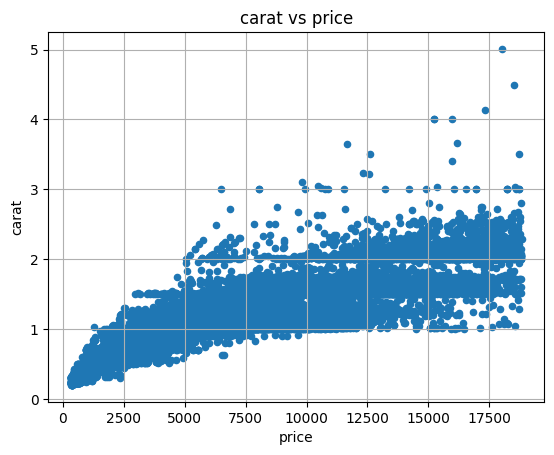

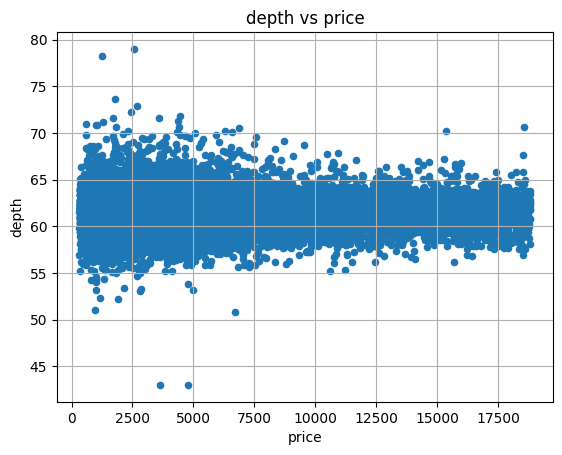

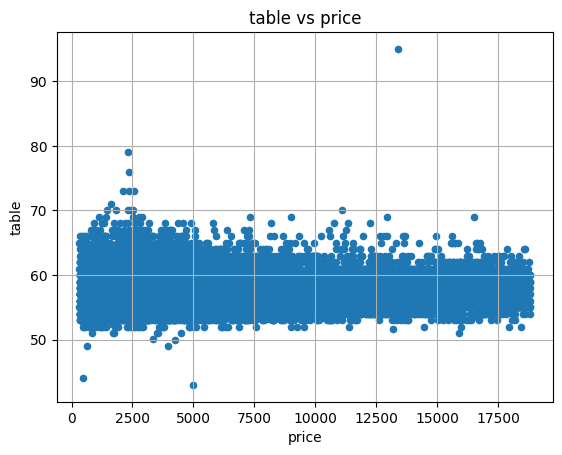

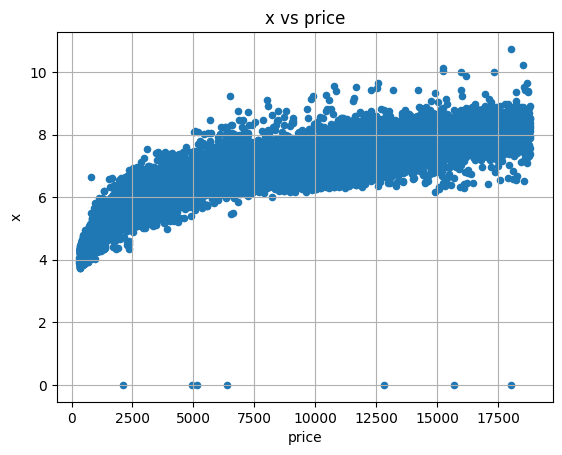

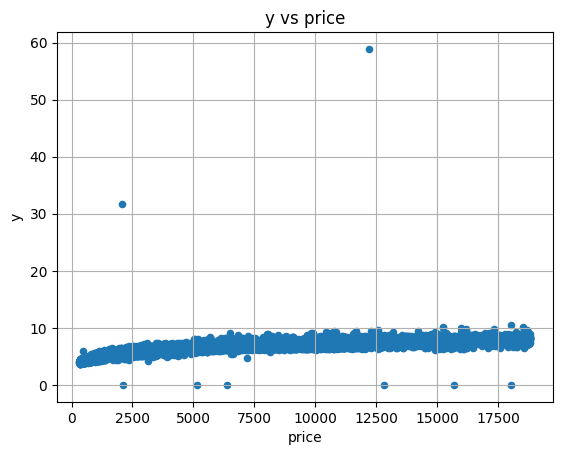

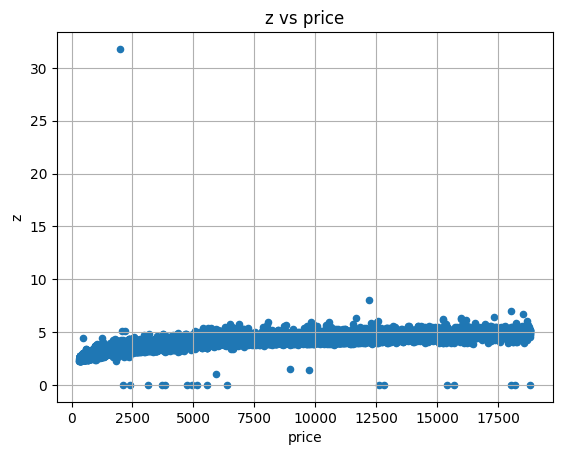

In [ ]:
for column in raw.select_dtypes(include="number").columns:
    if column != "price":
        raw.plot(
            kind="scatter", y=column, x="price", title=f"{column} vs price", grid=True
        )
        plt.show()

Нарисуем гистограммы значений и посмотрим, какие выбросы можно найти с помощью IQR

carat: mean=0.7993311144083088, std=0.47460189216729437
carat: IQR = 0.64; не выбросы: 0.2 < carat < 2.0; можно удалить 2019 значений(-я)


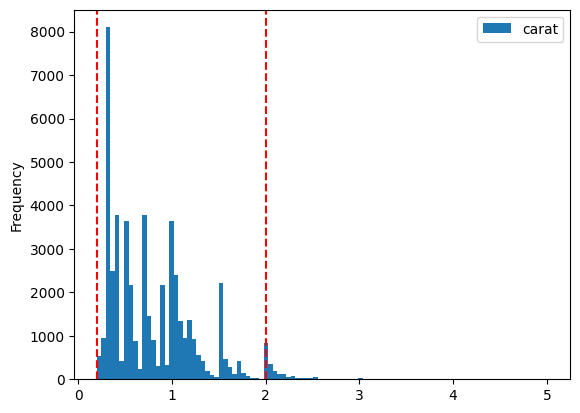

depth: mean=61.75180254240687, std=1.428192349497926
depth: IQR = 1.5; не выбросы: 58.75 < depth < 64.75; можно удалить 2340 значений(-я)


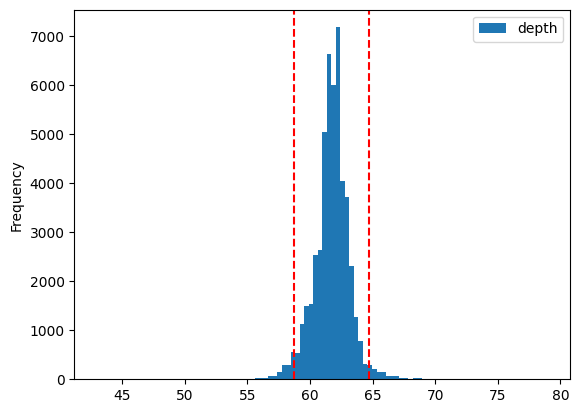

table: mean=57.45878614107551, std=2.2310651223668536
table: IQR = 3.0; не выбросы: 51.5 < table < 63.5; можно удалить 558 значений(-я)


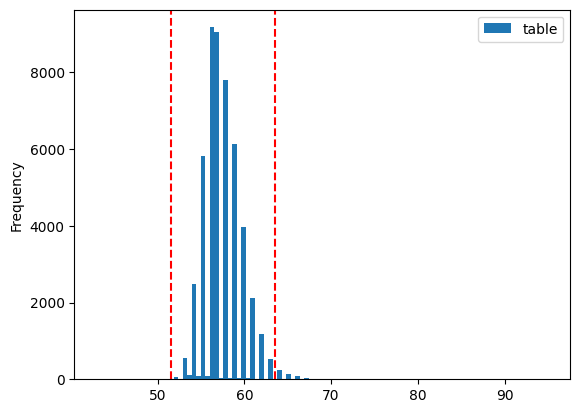

price: mean=3945.384569114168, std=3996.89926053189


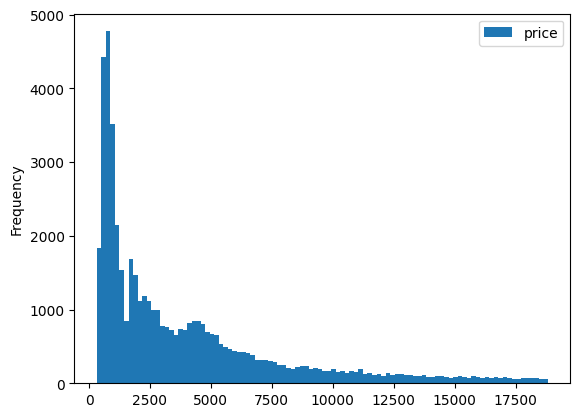

x: mean=5.7344407907927994, std=1.122328595015998
x: IQR = 1.8200000000000003; не выбросы: 1.9899999999999993 < x < 9.27; можно удалить 31 значений(-я)


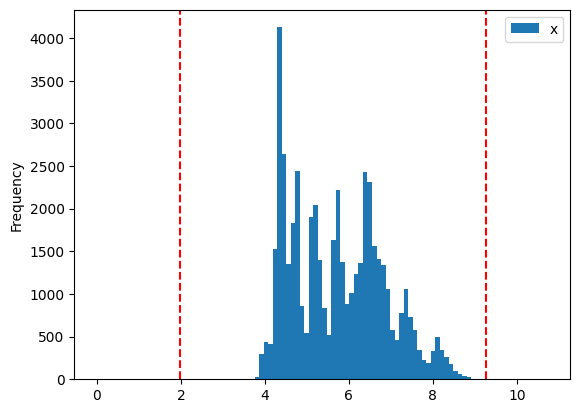

y: mean=5.738060111480932, std=1.1449615318110997
y: IQR = 1.8200000000000003; не выбросы: 1.9899999999999993 < y < 9.27; можно удалить 28 значений(-я)


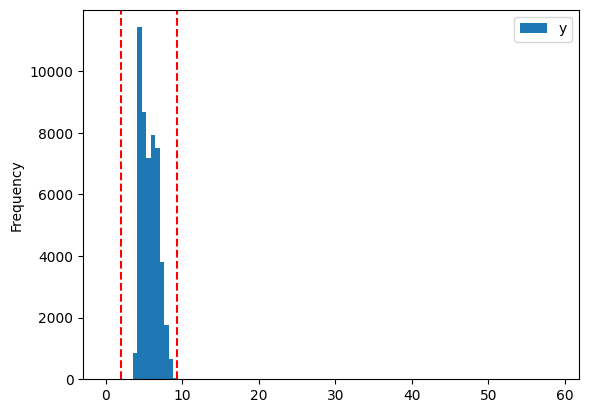

z: mean=3.5410281910414247, std=0.706599651015795
z: IQR = 1.13; не выбросы: 1.2150000000000003 < z < 5.734999999999999; можно удалить 43 значений(-я)


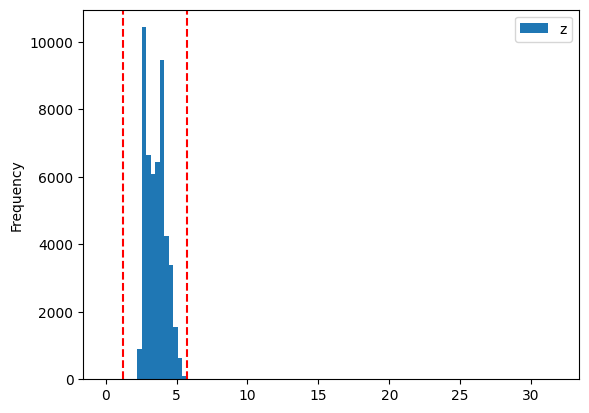

In [ ]:
def analyze_iqr(col_name, col):
    q1 = np.percentile(col, q=25)
    q3 = np.percentile(col, q=75)
    _iqr = iqr(col)
    left = max(col.min(), q1 - _iqr * 1.5)
    right = min(col.max(), q3 + _iqr * 1.5)
    print(
        f"{col_name}: IQR = {_iqr}; "
        f"не выбросы: {left} < {col_name} < {right}; "
        f"можно импутировать {(col <= left).sum() + (col >= right).sum()} значений(-я)"
    )
    return left, right


for column in raw.select_dtypes(include="number").columns:
    print(f"{column}: mean={np.mean(raw[column])}, std={np.std(raw[column])}")
    if column != "price":
        left, right = analyze_iqr(column, raw[column])
    raw[column].plot.hist(bins=100, legend=True)
    if column != "price":
        plt.axvline(x=left, color="red", linestyle="--")
        plt.axvline(x=right, color="red", linestyle="--")
    plt.show()